installation des packages

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error, r2_score
import joblib

load le cleaned fiile

In [124]:
df = pd.read_csv("cleaned_dataset.csv")
#df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10662 entries, 0 to 10661
Data columns (total 29 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   Date                                                                           10662 non-null  object 
 1   Service                                                                        10662 non-null  object 
 2   Departure station                                                              10131 non-null  object 
 3   Arrival station                                                                10126 non-null  object 
 4   Average journey time                                                           10662 non-null  float64
 5   Number of scheduled trains                                                     10662 non-null  int64  
 6   Number of cancelled tr

visualisations des colonnes en rapport avec le retard des trains mais plus avec la colonne is_delayed

In [125]:
""" sns.countplot(data=df, x="is_delayed")
plt.title("Retards vs Trains à l'heure")
plt.show() """

' sns.countplot(data=df, x="is_delayed")\nplt.title("Retards vs Trains à l\'heure")\nplt.show() '

visualisation avec heure

In [126]:
""" sns.barplot(data=df, x="Day of Week", y="is_delayed", estimator="mean")
plt.title("Proportion de retards par jour")
plt.xticks(rotation=45)
plt.show() """

' sns.barplot(data=df, x="Day of Week", y="is_delayed", estimator="mean")\nplt.title("Proportion de retards par jour")\nplt.xticks(rotation=45)\nplt.show() '

In [127]:
""" sns.barplot(data=df, x="Month", y="is_delayed", estimator="mean")
plt.title("Proportion de retards par Mois")
plt.xticks(rotation=45)
plt.show() """

' sns.barplot(data=df, x="Month", y="is_delayed", estimator="mean")\nplt.title("Proportion de retards par Mois")\nplt.xticks(rotation=45)\nplt.show() '

In [128]:
""" sns.barplot(data=df, x="Service", y="is_delayed", estimator="mean")
plt.title("Proportion de retards par service")
plt.xticks(rotation=45)
plt.show() """

' sns.barplot(data=df, x="Service", y="is_delayed", estimator="mean")\nplt.title("Proportion de retards par service")\nplt.xticks(rotation=45)\nplt.show() '

In [129]:
""" sns.countplot(data=df, x="Departure station")
plt.title("Proportion de retards par gare de depart")
plt.show() """

' sns.countplot(data=df, x="Departure station")\nplt.title("Proportion de retards par gare de depart")\nplt.show() '

In [130]:
"""
sns.countplot(data=df, x="Arrival station")
plt.title("Proportion de retards par gare d'arrivée")
plt.xticks(rotation=45)
plt.show()
"""

'\nsns.countplot(data=df, x="Arrival station")\nplt.title("Proportion de retards par gare d\'arrivée")\nplt.xticks(rotation=45)\nplt.show()\n'

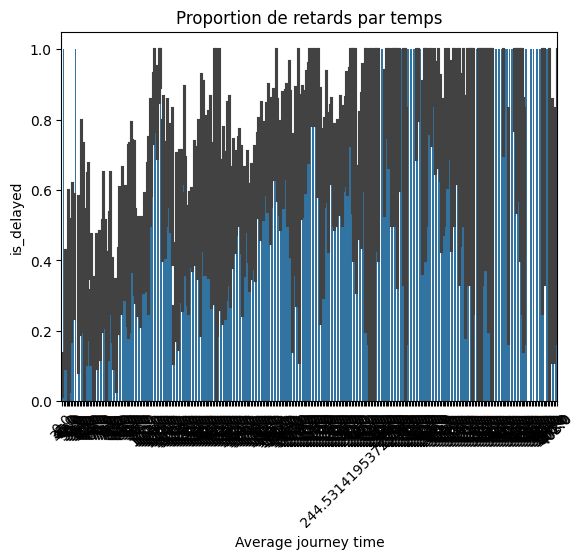

In [131]:

sns.barplot(data=df, x="Average journey time", y="is_delayed", estimator="mean")
plt.title("Proportion de retards par temps")
plt.xticks(rotation=45)
plt.show()


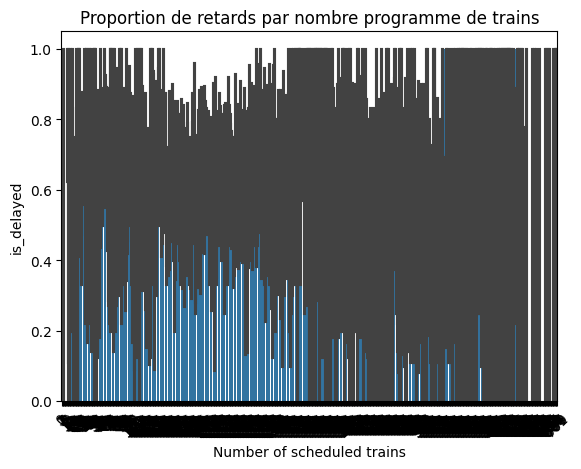

In [132]:
sns.barplot(data=df, x="Number of scheduled trains", y="is_delayed", estimator="mean")
plt.title("Proportion de retards par nombre programme de trains")
plt.xticks(rotation=45)
plt.show()


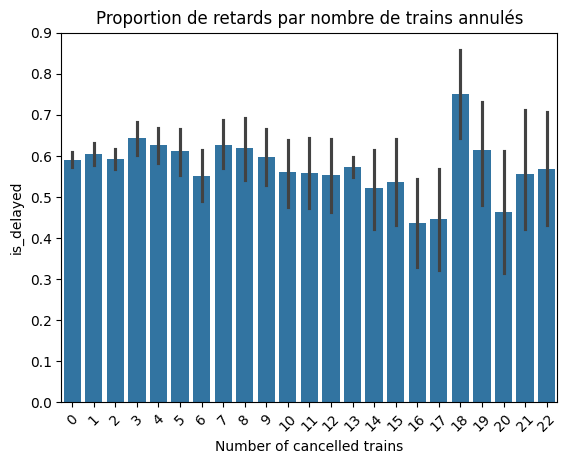

In [133]:
sns.barplot(data=df, x="Number of cancelled trains", y="is_delayed", estimator="mean")
plt.title("Proportion de retards par nombre de trains annulés")
plt.xticks(rotation=45)
plt.show()

visualisation des variables continues

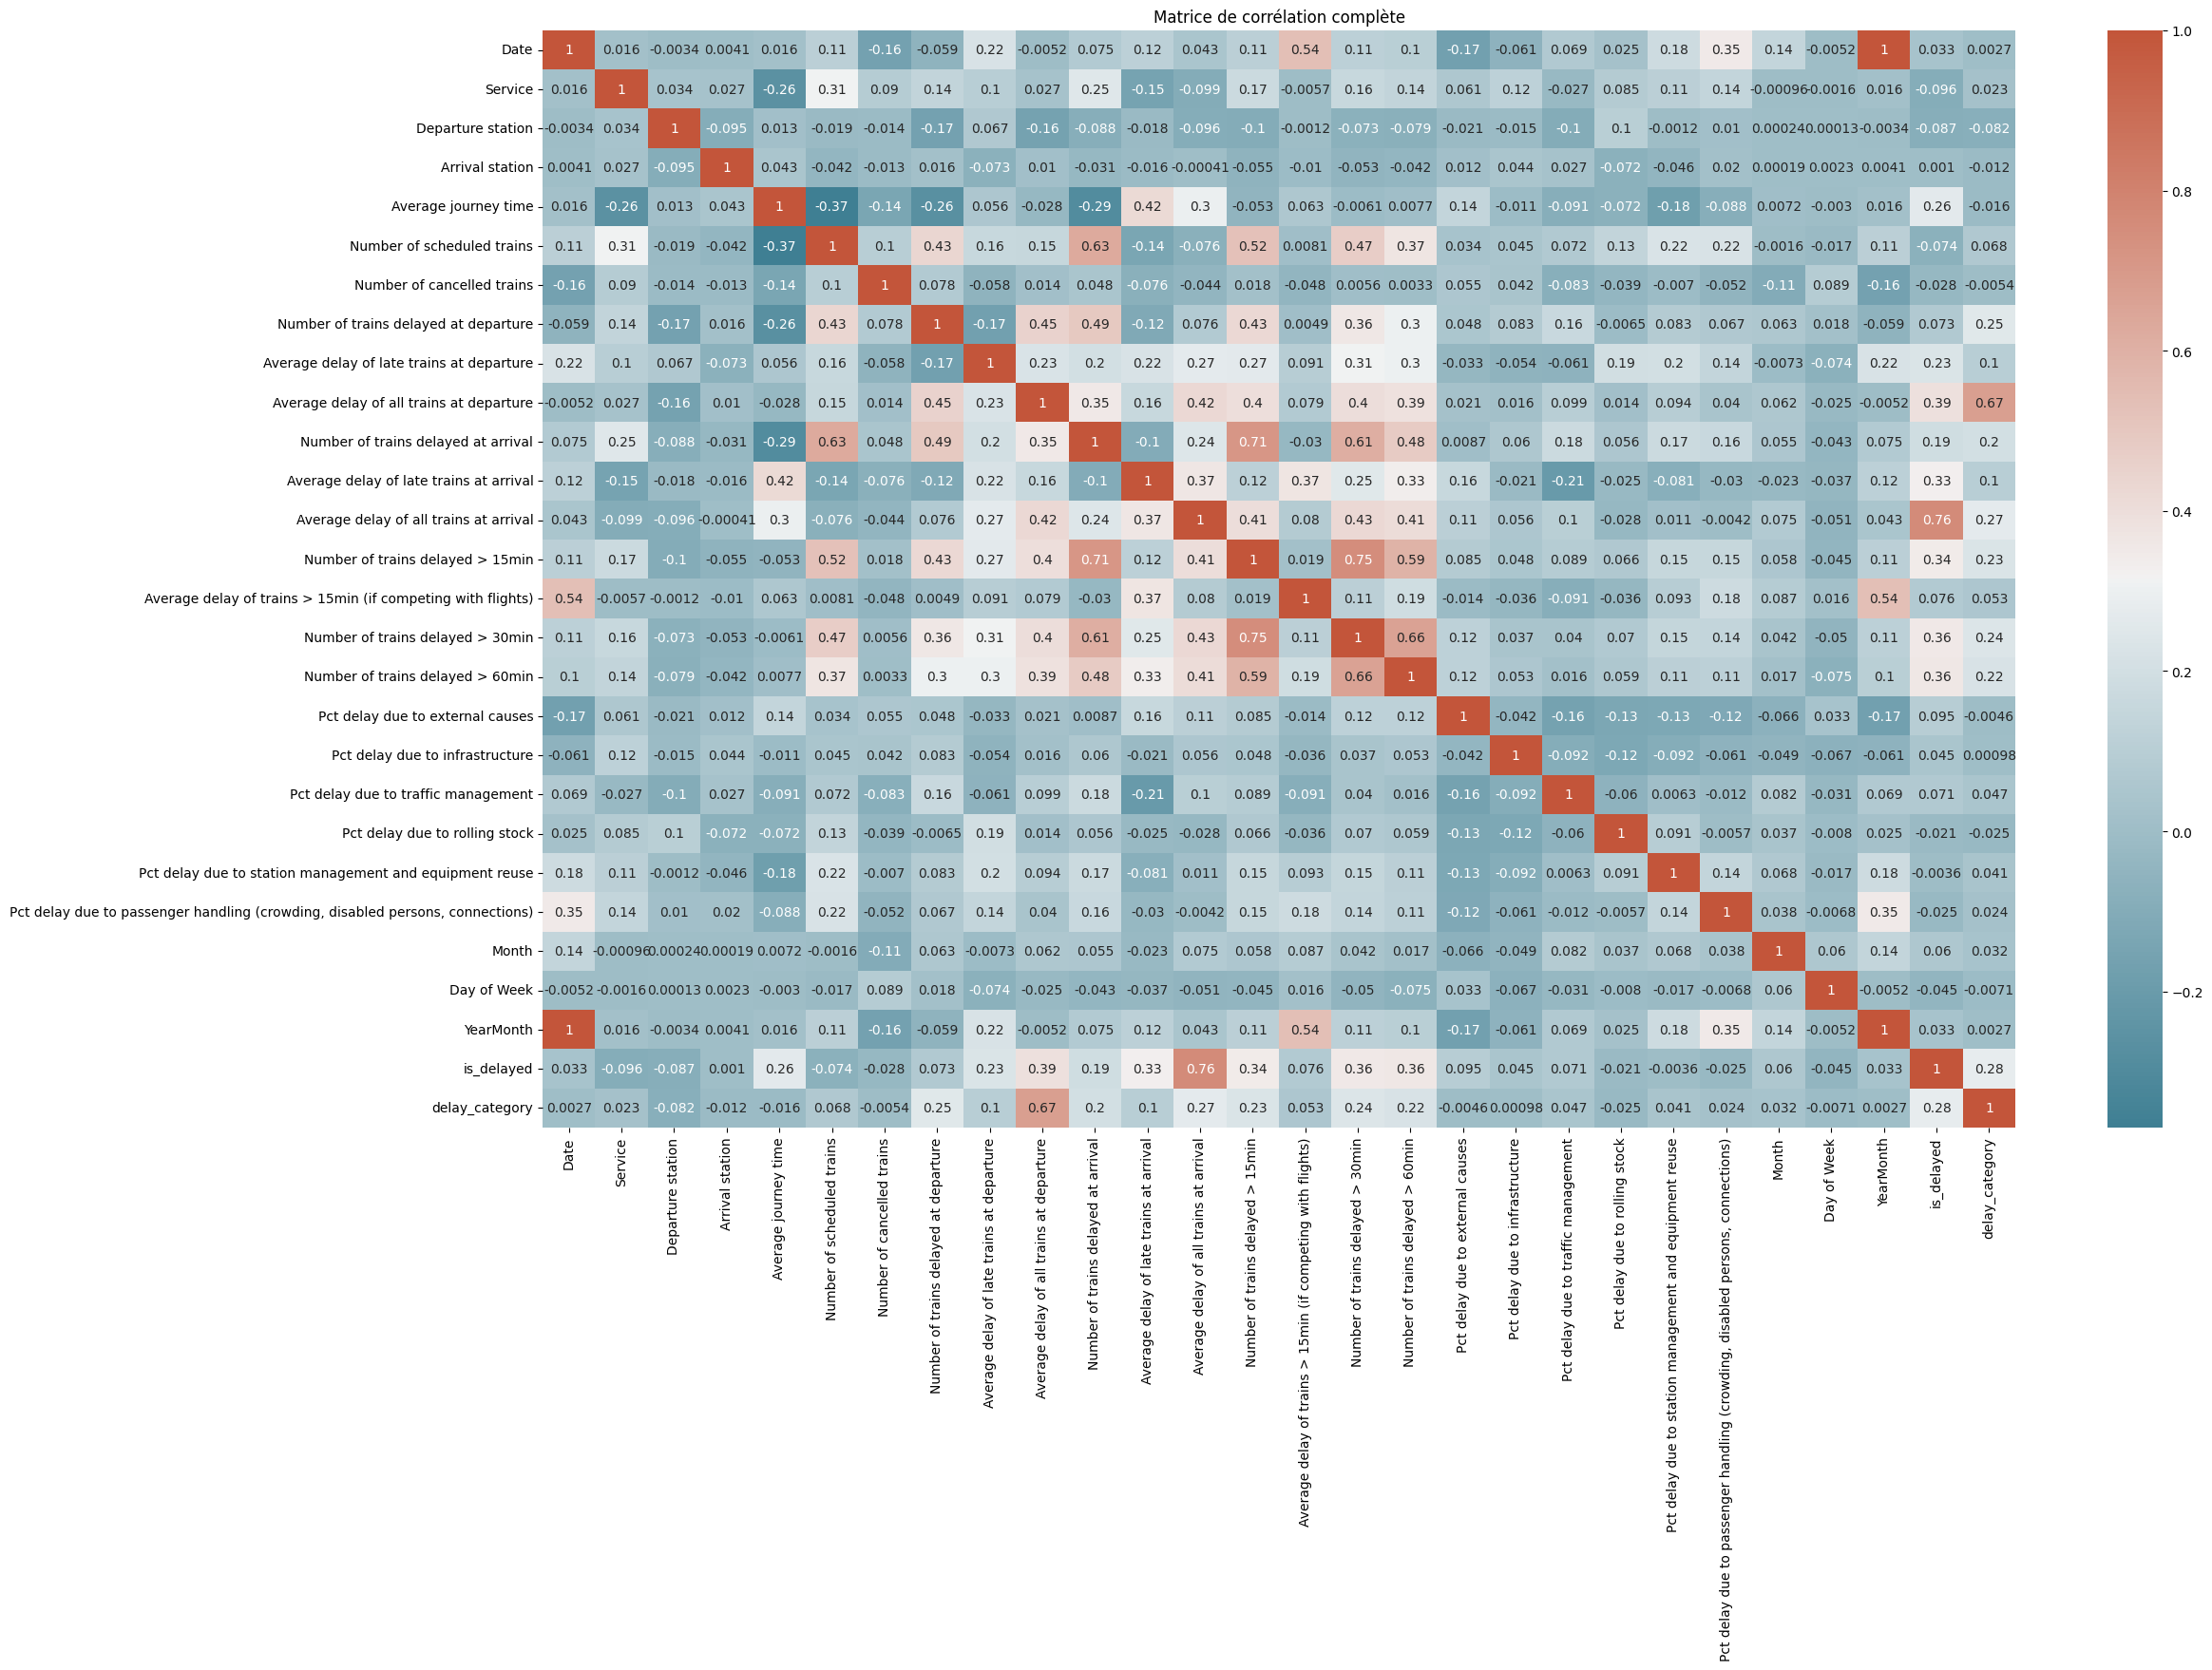

In [134]:
df_cop = df.copy()
encode = LabelEncoder()
for col in df_cop.select_dtypes(include="object").columns:
    df_cop[col] = encode.fit_transform(df_cop[col])

df_cop = df_cop.select_dtypes(include=["number"])
corr = df_cop.corr()
plt.figure(figsize=(25, 15))
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, annot=True,cmap=sns.diverging_palette(220,20,as_cmap=True))
plt.title("Matrice de corrélation complète")
plt.show()

/tmp/ipykernel_19775/509197990.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


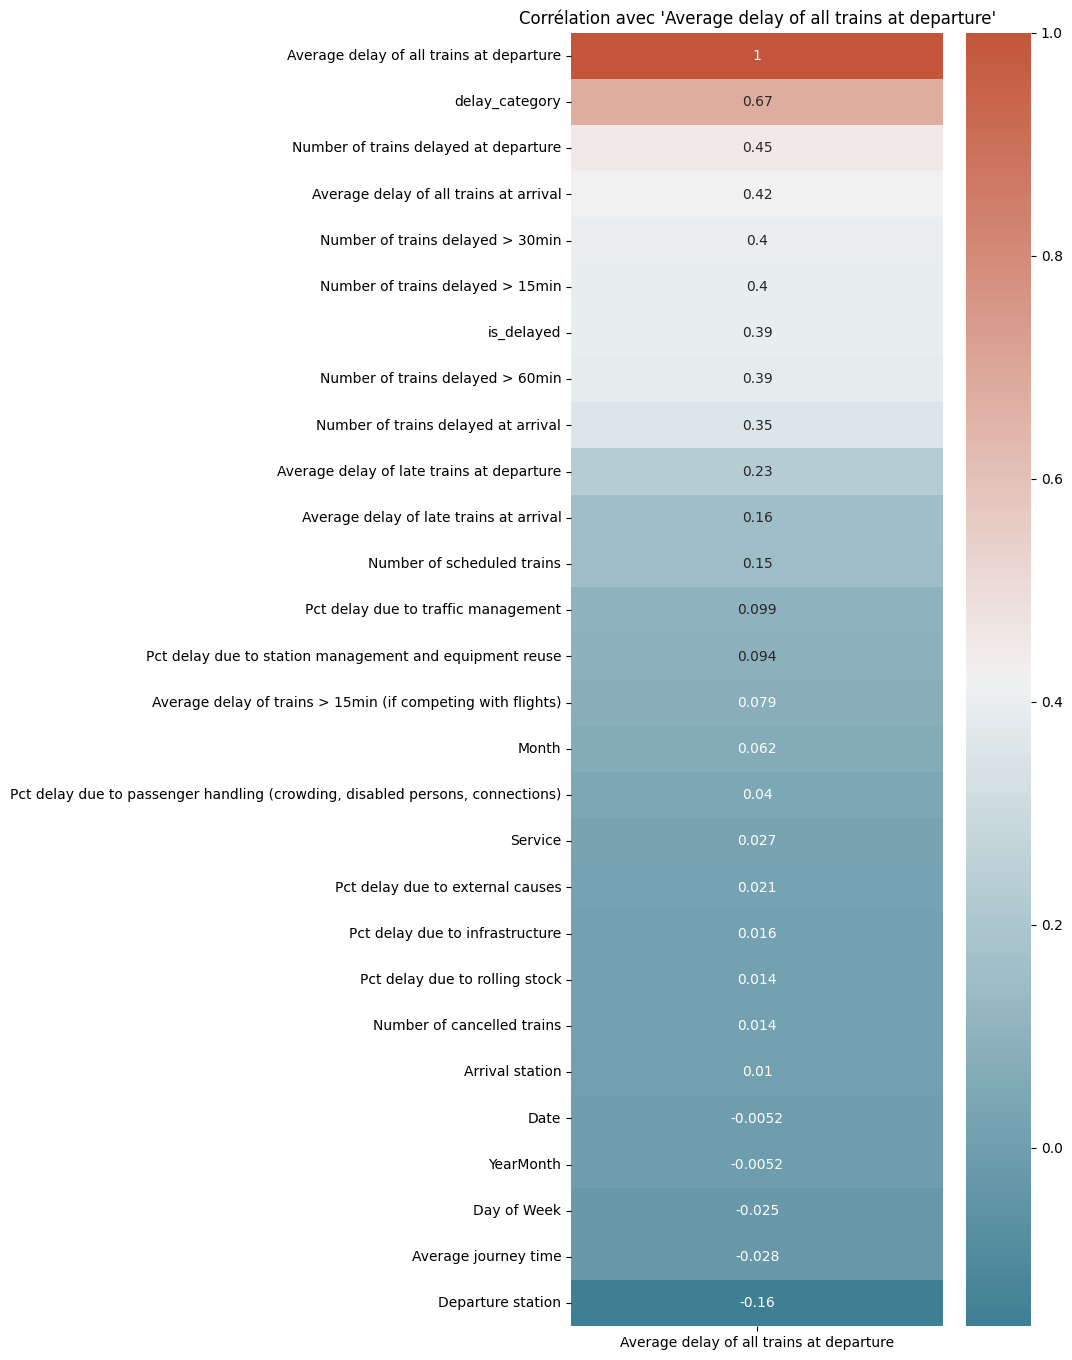

In [135]:
df_cop = df.copy()
encoder = LabelEncoder()
for col in df_cop.select_dtypes(include="object").columns:
    df_cop[col] = encoder.fit_transform(df_cop[col])

df_cop = df_cop.select_dtypes(include=["number"])
corr = df_cop.corr()
target = "Average delay of all trains at departure"
corr_target = corr[[target]].sort_values(by=target, ascending=False)
plt.figure(figsize=(6, len(corr_target) * 0.6))
sns.heatmap(corr_target, annot=True, cmap=sns.diverging_palette(220, 20, as_cmap=True))
plt.title(f"Corrélation avec '{target}'")
plt.tight_layout()
plt.show()


modele de prediction regression

In [136]:
Y_reg = df['Average delay of all trains at arrival']
feat = ["Service", "Departure station", "Arrival station", "Month", "Day of Week", "Number of scheduled trains", "Average journey time", "delay_category", "is_weekend"]
X_reg = df[feat]
encode = LabelEncoder()
for col in X_reg.select_dtypes(include="object").columns:
    X_reg[col] = encode.fit_transform(X_reg[col])

X_train, X_test, y_train, y_test = train_test_split(X_reg, Y_reg, test_size=0.2, random_state=42)

modl = LinearRegression()
modl.fit(X_train, y_train)

y_pred = modl.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 score: {r2:.2f}")

MAE: 2.09
RMSE: 2.69
R2 score: 0.17


/tmp/ipykernel_19775/3983308393.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_reg[col] = encode.fit_transform(X_reg[col])
/tmp/ipykernel_19775/3983308393.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_reg[col] = encode.fit_transform(X_reg[col])
/tmp/ipykernel_19775/3983308393.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

creer un modele de classification randomForestClassifier

In [137]:
Y = df['is_delayed']
features = ["Service", "Departure station", "Arrival station", "Month", "Day of Week", "is_weekend", "Number of scheduled trains", "Number of cancelled trains", "Average journey time"]
X = df[features]
encode = LabelEncoder()
for col in X.select_dtypes(include="object").columns:
    X[col] = encode.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model_first = RandomForestClassifier(n_estimators=100, random_state=42)
model_first.fit(X_train, y_train)

y_pred = model_first.predict(X_test)

print("Accuracy", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

/tmp/ipykernel_19775/1406198790.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encode.fit_transform(X[col])
/tmp/ipykernel_19775/1406198790.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encode.fit_transform(X[col])
/tmp/ipykernel_19775/1406198790.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stabl

Accuracy 0.706516643225504
Confusion matrix:
 [[533 371]
 [255 974]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.59      0.63       904
           1       0.72      0.79      0.76      1229

    accuracy                           0.71      2133
   macro avg       0.70      0.69      0.69      2133
weighted avg       0.70      0.71      0.70      2133



modele par classification logisticRegression

In [138]:
y = df['is_delayed']
feature = ["Service", "Departure station", "Arrival station", "Month", "Day of Week", "is_weekend", "Number of scheduled trains", "Number of cancelled trains", "Average journey time"]
x = df[feature]
encode = LabelEncoder()
for col in x.select_dtypes(include="object").columns:
    x[col] = encode.fit_transform(x[col])

x_train, x_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_ = LogisticRegression(random_state=42)
model_.fit(x_train, Y_train)

Y_pred = model_.predict(x_test)

print("Accuracy", accuracy_score(Y_test, Y_pred))
print("Confusion matrix:\n", confusion_matrix(Y_test, Y_pred))
print("Classification Report:\n", classification_report(Y_test, Y_pred))

Accuracy 0.6497890295358649
Confusion matrix:
 [[ 375  529]
 [ 218 1011]]
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.41      0.50       904
           1       0.66      0.82      0.73      1229

    accuracy                           0.65      2133
   macro avg       0.64      0.62      0.62      2133
weighted avg       0.65      0.65      0.63      2133



/tmp/ipykernel_19775/475489166.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col] = encode.fit_transform(x[col])
/tmp/ipykernel_19775/475489166.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col] = encode.fit_transform(x[col])
/tmp/ipykernel_19775/475489166.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

In [139]:
joblib.dump(modl, "model_regression.pkl")
joblib.dump(model_first, "model_classification.pkl")

['model_classification.pkl']